<h1>MonReader: Single Frame Modelling (SFM): Data Processing

Treat all images as their own row regardless of if they are frames part of the same clip. Sequential frames of the same clip are similar but slightly different so each image should in theory contribute information to model training.

In [32]:
import numpy as np
import pandas as pd
import os

In [33]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DATA_DIR = RAW_DATA_DIR / "training"
TEST_DATA_DIR = RAW_DATA_DIR / "testing"

<h3>Load All Training/Testing Data Into Single Datasets

In [34]:
import cv2

ALLOWED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.gif'}

def load_images_to_df(image_dir, label=None, label_from_subdir=True, split=None):
    """
    Load images into a DataFrame using cv2.imread.

    Images are converted from OpenCV's BGR format to RGB.
    """
    records = []
    image_dir = Path(image_dir)

    if not image_dir.is_dir():
        return pd.DataFrame(records)

    def _load_from_dir(directory, lbl):
        for root_dir, _, files in os.walk(directory):
            for fname in sorted(files):
                path = os.path.join(root_dir, fname)

                if Path(fname).suffix.lower() not in ALLOWED_EXTS:
                    continue

                image = cv2.imread(path, cv2.IMREAD_COLOR)
                if image is None:
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                records.append({
                    'image': image,
                    'label': lbl,
                    'split': split
                })

    if label_from_subdir:
        subdirs = [
            d for d in sorted(os.listdir(image_dir))
            if (image_dir / d).is_dir()
        ]

        if subdirs:
            for subdir in subdirs:
                _load_from_dir(image_dir / subdir, subdir)
        else:
            _load_from_dir(image_dir, label)
    else:
        _load_from_dir(image_dir, label)

    return pd.DataFrame(records)


In [35]:
raw_training = load_images_to_df(image_dir=TRAIN_DATA_DIR,
                             label=False,
                             label_from_subdir=True,
                             split='training')

In [36]:
raw_testing = load_images_to_df(image_dir=TEST_DATA_DIR,
                             label=False,
                             label_from_subdir=True,
                             split='testing')

In [37]:
raw_training.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   2392 non-null   object
 1   label   2392 non-null   str   
 2   split   2392 non-null   str   
dtypes: object(1), str(2)
memory usage: 13.9 GB


pandas likely underreports the size because image contains NumPy arrays inside an object column. Measure the image data directly:

In [38]:
image_bytes = raw_training["image"].map(lambda image: image.nbytes).sum()
print(f"Image data: {image_bytes / 1024**2:.2f} MB")
print(f"DataFrame reported: {raw_training.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Image data: 14190.82 MB
DataFrame reported: 14191.42 MB


In [39]:
image_bytes = raw_testing["image"].map(lambda image: image.nbytes).sum()
print(f"Image data: {image_bytes / 1024**2:.2f} MB")
print(f"DataFrame reported: {raw_testing.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Image data: 3541.77 MB
DataFrame reported: 3541.92 MB


My biggest concern at the moment is the size of the variables holding the images, as they are high resolution and each variable (train and test) will contain 1000s of rows. In total they are taking up ~17-18GB in memory

In [40]:
raw_training.head(5)

,image,label,split
0,"[[[145, 137, 118], [145, 137, 118], [145, 137,...",flip,training
1,"[[[145, 137, 118], [145, 137, 118], [145, 137,...",flip,training
2,"[[[144, 140, 113], [143, 139, 112], [142, 138,...",flip,training
3,"[[[144, 140, 113], [143, 139, 112], [142, 138,...",flip,training
4,"[[[149, 145, 118], [142, 138, 111], [135, 131,...",flip,training


In [41]:
print(f"Shape: {raw_training.shape}")
print(f"Image data-type: {type(raw_training["image"][0])}, Shape: {raw_training["image"][0].shape}")
print(f"Image format: {["RGB" if raw_training["image"][0].shape[2] == 3 else "Non-RGB"]}")

Shape: (2392, 3)
Image data-type: <class 'numpy.ndarray'>, Shape: (1920, 1080, 3)
Image format: ['RGB']


We'll need to convert the RGB images here into grayscale like we did in the last notebook. store the new variables, then wipe the raw varaibles from memory for efficiency i.e. Garbage collection.

e.g.

import gc

del x

gc.collect()

In [42]:
import gc
del raw_training
del raw_testing
gc.collect()

21

In [43]:
def convert_images_to_grayscale(df):
    """
    Return a copy of df with images converted from RGB to grayscale.
    """
    grayscale_df = df.copy()
    grayscale_df["image"] = grayscale_df["image"].map(
        lambda image: cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    )
    return grayscale_df

Import raw data -> Use the grayscale conversion function - > Delete the raw data set from memory for efficiency:

In [ ]:
# Training

raw_training = load_images_to_df(image_dir=TRAIN_DATA_DIR,
                             label=False,
                             label_from_subdir=True,
                             split='training')

gray_training = convert_images_to_grayscale(raw_training)

del raw_training #GC

gray_training.head(5)

print(f"Shape: {gray_training.shape}")
print(f"Image data-type: {type(gray_training["image"][0])}, Shape: {gray_training["image"][0].shape}")
image_bytes = gray_training["image"].map(lambda image: image.nbytes).sum()
print(f"Image data: {image_bytes / 1024**2:.2f} MB")
print(f"DataFrame reported: {gray_training.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (2392, 3)
Image data-type: <class 'numpy.ndarray'>, Shape: (1920, 1080)
Image data: 4730.27 MB
DataFrame reported: 4730.84 MB


Training set was ~14GB before, now it's ~5GB. Massive improvement

In [ ]:
# Testing

raw_testing = load_images_to_df(image_dir=TEST_DATA_DIR,
                             label=False,
                             label_from_subdir=True,
                             split='testing')

gray_testing = convert_images_to_grayscale(raw_testing)

del raw_testing #GC

gray_testing.head(5)

print(f"Shape: {gray_testing.shape}")
print(f"Image data-type: {type(gray_testing["image"][0])}, Shape: {gray_testing["image"][0].shape}")
image_bytes = gray_testing["image"].map(lambda image: image.nbytes).sum()
print(f"Image data: {image_bytes / 1024**2:.2f} MB")
print(f"DataFrame reported: {gray_testing.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (597, 3)
Image data-type: <class 'numpy.ndarray'>, Shape: (1920, 1080)
Image data: 1180.59 MB
DataFrame reported: 1180.73 MB


1) Resize images to a smaller size + add channel dimension (1 = grayscale, 3 = RGB).
2) Separate into X and y.
3) Normalise pixel values + make sure datatype = float32.
4) Encode the labels.
5) Save as pkl files in 'processed' ready for modelling.

In [46]:
def resize_image(image, scale_factor=0.5):
    """
    Resize a grayscale image by a fixed scale factor while preserving aspect ratio.
    """
    height, width = image.shape[:2]
    new_width = max(1, int(width * scale_factor))
    new_height = max(1, int(height * scale_factor))

    return cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)

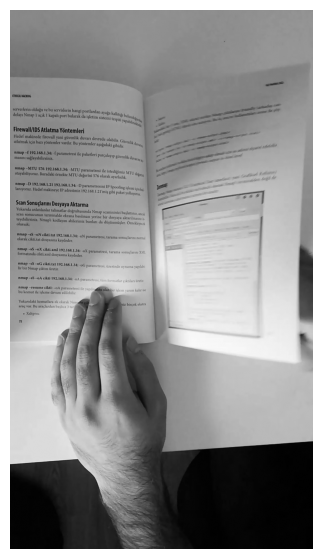

In [47]:
import matplotlib.pyplot as plt

gray_image = gray_training["image"][0]

plt.figure(figsize=(12, 7))
plt.imshow(gray_image, cmap="gray") #Default imshow colour is green. Specify gray here
plt.axis("off")
plt.show()

(480, 270)


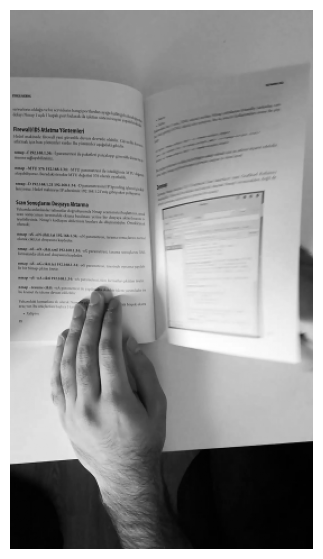

In [48]:
small_gray_image = resize_image(gray_image, 0.25)
print(small_gray_image.shape)
plt.figure(figsize=(12, 7))
plt.imshow(small_gray_image, cmap="gray") #Default imshow colour is green. Specify gray here
plt.axis("off")
plt.show()

Halving image size doesn't appear to cost much visual resolution? Can we reduce image size to reduce eventual model size without sacrificing too much information?

In [49]:
def resize_images_in_df(df, scale_factor=0.5):
    """
    Return a copy of df with all images resized by scale_factor.
    """
    resized_df = df.copy()
    resized_df["image"] = resized_df["image"].map(
        lambda image: resize_image(image, scale_factor)
    )
    return resized_df

In [50]:
gray_training = resize_images_in_df(gray_training, 0.25)
gray_testing = resize_images_in_df(gray_testing, 0.25)

Check new size in memory:

In [51]:
# Training:
print(f"Shape: {gray_training.shape}")
print(f"Image data-type: {type(gray_training["image"][0])}, Shape: {gray_training["image"][0].shape}")
image_bytes = gray_training["image"].map(lambda image: image.nbytes).sum()
print(f"Image data: {image_bytes / 1024**2:.2f} MB")
print(f"DataFrame reported: {gray_training.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (2392, 3)
Image data-type: <class 'numpy.ndarray'>, Shape: (480, 270)
Image data: 295.64 MB
DataFrame reported: 296.21 MB


In [52]:
# Testing:
print(f"Shape: {gray_testing.shape}")
print(f"Image data-type: {type(gray_testing["image"][0])}, Shape: {gray_testing["image"][0].shape}")
image_bytes = gray_testing["image"].map(lambda image: image.nbytes).sum()
print(f"Image data: {image_bytes / 1024**2:.2f} MB")
print(f"DataFrame reported: {gray_testing.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (597, 3)
Image data-type: <class 'numpy.ndarray'>, Shape: (480, 270)
Image data: 73.79 MB
DataFrame reported: 73.93 MB


Much better. Should make adding the color channel (fixed value of 1 or 3 for G or RGB respectively) that TensorFlow models require better.

In [53]:
def add_grayscale_channel(df):
    """
    Return a copy of the DataFrame with grayscale images shaped as
    (height, width, 1) for TensorFlow models.
    """
    channel_df = df.copy()
    channel_df["image"] = channel_df["image"].map(
        lambda image: image[..., np.newaxis]
        if image.ndim == 2
        else image
    )
    return channel_df


gray_training = add_grayscale_channel(gray_training)
gray_testing = add_grayscale_channel(gray_testing)

In [54]:
# Training
print(f"Shape: {gray_training.shape}")
print(f"Image data-type: {type(gray_training["image"][0])}, Shape: {gray_training["image"][0].shape}")
image_bytes = gray_training["image"].map(lambda image: image.nbytes).sum()
print(f"Image data: {image_bytes / 1024**2:.2f} MB")
print(f"DataFrame reported: {gray_training.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (2392, 3)
Image data-type: <class 'numpy.ndarray'>, Shape: (480, 270, 1)
Image data: 295.64 MB
DataFrame reported: 0.60 MB


In [55]:
# Testing
print(f"Shape: {gray_testing.shape}")
print(f"Image data-type: {type(gray_testing["image"][0])}, Shape: {gray_testing["image"][0].shape}")
image_bytes = gray_testing["image"].map(lambda image: image.nbytes).sum()
print(f"Image data: {image_bytes / 1024**2:.2f} MB")
print(f"DataFrame reported: {gray_testing.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Shape: (597, 3)
Image data-type: <class 'numpy.ndarray'>, Shape: (480, 270, 1)
Image data: 73.79 MB
DataFrame reported: 0.15 MB


Tiny increase in memory size.

In [56]:
X_train = gray_training["image"]
y_train = gray_training["label"]
X_test = gray_testing["image"]
y_test = gray_testing["label"]

Next is to normalise the X values to between 0-1 as float32 types. This is done by dividing the brightness values by 255 (the maximum possible brightness value).

In [57]:
def normalize_images(images):
    """Normalize image pixel values to the range [0, 1] as float32."""
    return images.map(lambda image: image.astype(np.float32) / 255.0)

X_train = normalize_images(X_train)
X_test = normalize_images(X_test)

In [58]:
X_train[0].shape

(480, 270, 1)

In [59]:
X_test[0].shape

(480, 270, 1)

The shape hasn't changed which is good, only the pixel values have. The model will still be able to determine that it is grayscale not RGB (single vs triple channel).

Encode the the labels to binary. Here we will make 'flip' the positive class (and vice-versa).

In [60]:
def encode_labels(labels):
    """Encode 'flip' as 1 and all other labels as 0."""
    return labels.map(lambda label: 1 if label == "flip" else 0)

y_train = encode_labels(y_train)
y_test = encode_labels(y_test)

Then convert the Pandas Series to single numpy arrays to avoid indexing issues when a validation set (to be created) is split from the training set randomly causing an inordered index

In [61]:
X_train = np.stack(X_train.to_numpy())
X_test = np.stack(X_test.to_numpy())

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

And finall save the processed data ready for modelling.

In [62]:
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SFM_DATA_DIR = PROCESSED_DATA_DIR / "sfm"

In [63]:
SFM_DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.to_pickle(X_train, SFM_DATA_DIR / "X_train.pkl")
pd.to_pickle(y_train, SFM_DATA_DIR / "y_train.pkl")
pd.to_pickle(X_test, SFM_DATA_DIR / "X_test.pkl")
pd.to_pickle(y_test, SFM_DATA_DIR / "y_test.pkl")